# Twin-2K-500 — Data Exploration

**Deliverable 1** for the Research Engineer take-home. This notebook:

1. Loads both Hugging Face configs (`full_persona`, `wave_split`) plus the question catalog and response CSVs.
2. Profiles dataset structure, question types, and how each type should be scored.
3. Checks sample distributions against U.S. Census benchmarks (representativeness).
4. Computes descriptive human test–retest statistics by question type and documents the paper's **81.72% mean accuracy across 17 tasks**. The official 17-task score is cited, not reproduced here.
5. Demonstrates the leakage trap (wave-4 labels in `full_persona`) and shows that earlier answers to the same held-out items live in a separate field (`wave4_Q_wave1_3_A`).
6. Documents the dataset's biases and limitations.
7. Exports the full key tables to a multi-sheet `.xlsx` for inspection.

The human test–retest result is an empirical short-term benchmark, not a mathematical upper bound. A model should beat trivial baselines and approach this benchmark; an unexpectedly higher result should trigger a leakage audit.

> **Reproducibility:** the first run downloads the Hugging Face dataset (~700 MB); later runs reuse the cache. Build model inputs from `wave_split`, strip answers from wave-4 question payloads, and keep those answers only as targets. Join column types through `csv_columns`, never `startswith(QuestionID)`.


## 1. Setup

In [1]:
# From the notebook directory: pip install -r ../requirements.txt

import json
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except ImportError:
    pass

from huggingface_hub import hf_hub_download
from datasets import load_dataset

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

REPO_ID = "LLM-Digital-Twin/Twin-2K-500"
DATASET_REVISION = "f883165a3026fde855dfd448e0cd16443ab257b6"


## 2. Dataset structure


**Hugging Face configs.** The dataset card documents **5 logical folders** but exposes **2 loadable HF configs** (the other 3—question catalog/CSV, LLM simulation results, and raw Qualtrics exports—are standalone files fetched with `hf_hub_download`):

| Config | Rows | Purpose |
|---|---|---|
| `full_persona` | 2,058 | One row per participant: `persona_text`, `persona_summary`, and `persona_json`. Repeated questions already use wave-4 answers, so `persona_text` and `persona_json` leak prediction targets. |
| `wave_split` | 2,058 | Temporal modeling interface: waves 1–3 persona fields, repeated questions paired with their earlier answers for test–retest analysis, and repeated questions paired with wave-4 answers as prediction targets. It is not a person-level train/validation/test split. |

Both configs are inspected below. Quantitative distributions and reliability statistics use the standalone standardized CSVs, which are easier to analyze than nested persona JSON. Section 6 cross-checks the HF fields against the CSV values for one repeated item.

In [2]:
full_persona = load_dataset(
    REPO_ID, "full_persona", revision=DATASET_REVISION
)["data"].to_pandas()
wave_split = load_dataset(
    REPO_ID, "wave_split", revision=DATASET_REVISION
)["data"].to_pandas()

# HF schema mismatch: full_persona.pid is string ("574"), wave_split.pid is int64 (574).
# Normalize so later merges / set comparisons work.
full_persona["pid"] = pd.to_numeric(full_persona["pid"], errors="raise").astype("int64")
wave_split["pid"] = pd.to_numeric(wave_split["pid"], errors="raise").astype("int64")

print("Dataset revision:", DATASET_REVISION)
print("full_persona:", full_persona.shape, " pid dtype:", full_persona["pid"].dtype)
print("wave_split  :", wave_split.shape, " pid dtype:", wave_split["pid"].dtype)
full_persona.head(2)


Dataset revision: f883165a3026fde855dfd448e0cd16443ab257b6
full_persona: (2058, 4)  pid dtype: int64
wave_split  : (2058, 5)  pid dtype: int64


,pid,persona_text,persona_summary,persona_json
0,574,Which part of the United States do you current...,The following is a description of a person.\n\...,"[{""ElementType"": ""Block"", ""BlockName"": ""Demogr..."
1,2001,Which part of the United States do you current...,The following is a description of a person.\n\...,"[{""ElementType"": ""Block"", ""BlockName"": ""Demogr..."


In [3]:
wave_split.columns.tolist()


['pid',
 'wave1_3_persona_text',
 'wave1_3_persona_json',
 'wave4_Q_wave1_3_A',
 'wave4_Q_wave4_A']

In [4]:
# Sanity check: same 2,058 participants in both configs?
assert set(full_persona["pid"]) == set(wave_split["pid"])
print(f"{full_persona['pid'].nunique()} unique participants, consistent across both configs.")


2058 unique participants, consistent across both configs.


**Tabular layer.** Numerical distributions and reliability statistics use the standardized CSVs rather than parsing `persona_json`. Section 6 checks one repeated item across both representations before treating them as aligned.


In [5]:
catalog_path = hf_hub_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    revision=DATASET_REVISION,
    filename="question_catalog_and_human_response_csv/question_catalog.json",
)
with open(catalog_path, encoding="utf-8") as f:
    question_catalog = json.load(f)

print(f"{len(question_catalog)} QuestionIDs in the catalog. "
      "The paper's ~500 count is administered questions; "
      "matrix rows and multi-select options expand these QIDs into the CSV columns loaded below.")

w13_num = pd.read_csv(hf_hub_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    revision=DATASET_REVISION,
    filename="question_catalog_and_human_response_csv/wave1_3_response.csv",
))
w4_num = pd.read_csv(hf_hub_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    revision=DATASET_REVISION,
    filename="question_catalog_and_human_response_csv/wave4_response.csv",
))

print("wave1_3_response.csv:", w13_num.shape, " (2,058 people x 761 columns incl. pid)")
print("wave4_response.csv  :", w4_num.shape, " (2,058 people x 127 columns incl. pid)")

# Official catalog field is `csv_columns` (a list). Do NOT match with
# col.startswith(QuestionID): QID290_5 would hit QID2 / QID29 first and
# mislabel Slider 0-100 items as MC/Matrix.
COL_TO_QUESTION = {}
for _q in question_catalog:
    for _c in _q.get("csv_columns") or []:
        COL_TO_QUESTION[_c] = _q

def question_meta(col: str) -> dict:
    q = COL_TO_QUESTION.get(col)
    if q is None:
        return {"qid": None, "qtype": "Unknown", "selector": None, "block": None,
                "is_descriptive": False, "range": None, "text": None}
    settings = q.get("Settings") or {}
    return {
        "qid": q.get("QuestionID"),
        "qtype": q.get("QuestionType") or "Unknown",
        "selector": settings.get("Selector"),
        "block": (q.get("BlockName") or "").strip(),
        "is_descriptive": bool(q.get("is_descriptive")),
        "range": q.get("Range"),
        "text": q.get("QuestionText"),
    }

n_unmapped = sum(1 for c in w13_num.columns if c != "pid" and c not in COL_TO_QUESTION)
print(f"Catalog csv_columns index: {len(COL_TO_QUESTION)} columns; "
      f"wave1-3 columns not in catalog: {n_unmapped}")


256 QuestionIDs in the catalog. The paper's ~500 count is administered questions; matrix rows and multi-select options expand these QIDs into the CSV columns loaded below.
wave1_3_response.csv: (2058, 761)  (2,058 people x 761 columns incl. pid)
wave4_response.csv  : (2058, 127)  (2,058 people x 127 columns incl. pid)
Catalog csv_columns index: 760 columns; wave1-3 columns not in catalog: 0


## 3. Question types and scoring


`question_catalog.json` gives a Qualtrics `QuestionType` per QuestionID (`MC`, `Matrix`, `Slider`, `TE`, `DB`) plus `csv_columns` — the actual CSV fields. One Matrix/Slider QuestionID expands to many scored items. **MC is not always single-choice:** `Settings.Selector` is `SAVR`/`SAHR` (single) or `MAVR`/`MAHR` (multi-select, e.g. BDI). **DB is instructional** (`is_descriptive: true`) and produces zero CSV columns — exclude it from scoring, do not treat it as "case-by-case".

In [6]:
qtype_counts = Counter(q.get("QuestionType", "Unknown") for q in question_catalog)
qtype_counts_df = (pd.Series(qtype_counts, name="n_QuestionIDs")
                     .sort_values(ascending=False)
                     .rename_axis("QuestionType")
                     .reset_index())
qtype_counts_df


,QuestionType,n_QuestionIDs
0,MC,175
1,Matrix,36
2,TE,28
3,DB,14
4,Slider,3


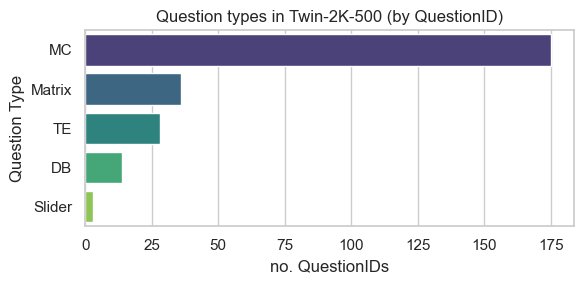

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(
    data=qtype_counts_df,
    x="n_QuestionIDs",
    y="QuestionType",
    hue="QuestionType",
    legend=False,
    ax=ax,
    palette="viridis",
)
ax.set_title("Question types in Twin-2K-500 (by QuestionID)")
ax.set_xlabel("no. QuestionIDs")
ax.set_ylabel("Question Type")
plt.tight_layout()
plt.show()


**Scoring mapping** (used later in `docs/03_eval_strategy.md`). Catalog counts below are the full 256-QuestionID file, not the held-out wave-4 set. Section 5 measures wave 4 from the CSV overlap: **84 QuestionIDs** (68 MC + 7 Matrix + 6 TE + 3 Slider) expanding to **126** response columns.

| QuestionType | Full catalog | Wave-4 scored set | Scoring metric |
|---|---|---|---|
| MC, selector SAVR/SAHR | **154** QuestionIDs (region, gender, pricing yes/no, …) | **68** of the 84 wave-4 QuestionIDs (68 columns) | Exact-match accuracy. Cohen's κ vs chance. MAE-on-code **only** if options are ordinal |
| MC, selector MAVR/MAHR | **21** QuestionIDs (BDI items, Wason) | **0** of the 126 wave-4 columns | Jaccard / per-option F1 — **not** single-label accuracy |
| Matrix | 36 QuestionIDs (Big Five rows, bipolar economic items) | 7 QuestionIDs / 40 columns | Ordinal MAE + range-normalized (MAD) accuracy. Exact-match alone is incomplete ("off by 1" ≠ "off by 4") |
| Slider | 3 QuestionIDs → 12 CSV columns, range 0–100 (`QID154`, `QID156`, `QID290_*`) | 3 QuestionIDs / 12 columns | Native 0–100 MAE + MAD accuracy. Exact-match is the wrong headline |
| TE | 28 QuestionIDs (`{QID}_TEXT` or form slots) | 6 numeric / anchoring columns | Native MAE as a diagnostic; the paper-comparable score first converts unbounded answers into deciles |
| DB | 14 blocks | 0 columns | **Exclude** — no answer is collected |

The paper-comparable headline is range-normalized accuracy: `1 − |prediction − target| / response range` (MAD accuracy in Deliverable 3). The type-specific metrics above are reported alongside it. There is no separate `MaxDiff` / `Multi-select` type in this catalog. Multi-select lives under MC.


In [8]:
MC_MULTI = {"MAVR", "MAHR"}

def scoring_metric(qtype: str, selector: str = None) -> str:
    if qtype == "MC" and selector in MC_MULTI:
        return "Jaccard / per-option F1 (multi-select; not single-label accuracy)"
    mapping = {
        "MC": "exact-match accuracy; Cohen's κ; MAE-on-code only if ordinal",
        "Matrix": "ordinal MAE + range-normalized (MAD) accuracy",
        "Slider": "native 0-100 MAE + MAD accuracy (not exact-match)",
        "TE": "MAD after deciles for unbounded numeric; native MAE as diagnostic",
        "DB": "exclude — instructional text, no answer collected",
    }
    return mapping.get(qtype, "case-by-case (inspect options/scale)")

mc_selector_counts = Counter(
    (q.get("Settings") or {}).get("Selector", "Unknown")
    for q in question_catalog if q.get("QuestionType") == "MC"
)
print("MC selectors (QuestionID level):", dict(mc_selector_counts))
n_single = mc_selector_counts.get("SAVR", 0) + mc_selector_counts.get("SAHR", 0)
n_multi = mc_selector_counts.get("MAVR", 0) + mc_selector_counts.get("MAHR", 0)
print(f"MC single-choice in full catalog (SAVR+SAHR): {n_single}")
print(f"MC multi-select in full catalog (MAVR+MAHR): {n_multi}")
print("DB with is_descriptive=True:",
      sum(1 for q in question_catalog if q.get("is_descriptive")))

# Rebuild from the catalog each run so this cell is safe to re-execute.
type_counts = Counter(q.get("QuestionType", "Unknown") for q in question_catalog)
scoring_rows = [
    {
        "QuestionType": "MC (SAVR/SAHR)",
        "n_QuestionIDs": n_single,
        "suggested_metric": scoring_metric("MC", "SAVR"),
    },
    {
        "QuestionType": "MC (MAVR/MAHR)",
        "n_QuestionIDs": n_multi,
        "suggested_metric": scoring_metric("MC", "MAVR"),
    },
]
for qtype in ["Matrix", "TE", "DB", "Slider"]:
    scoring_rows.append({
        "QuestionType": qtype,
        "n_QuestionIDs": type_counts.get(qtype, 0),
        "suggested_metric": scoring_metric(qtype),
    })
qtype_df = pd.DataFrame(scoring_rows)
qtype_df


MC selectors (QuestionID level): {'SAVR': 129, 'SAHR': 25, 'MAVR': 20, 'MAHR': 1}
MC single-choice in full catalog (SAVR+SAHR): 154
MC multi-select in full catalog (MAVR+MAHR): 21
DB with is_descriptive=True: 14


,QuestionType,n_QuestionIDs,suggested_metric
0,MC (SAVR/SAHR),154,exact-match accuracy; Cohen's κ; MAE-on-code o...
1,MC (MAVR/MAHR),21,Jaccard / per-option F1 (multi-select; not sin...
2,Matrix,36,ordinal MAE + range-normalized (MAD) accuracy
3,TE,28,MAD after deciles for unbounded numeric; nativ...
4,DB,14,"exclude — instructional text, no answer collected"
5,Slider,3,native 0-100 MAE + MAD accuracy (not exact-match)


## 4. Sample distributions and representativeness


The paper and dataset card describe the sample as representative of U.S. adults. I compare five unweighted demographic marginals—age, sex assigned at birth, region, family income, and education—with 2023 U.S. Census benchmarks. Exact response columns are identified through `question_catalog.json` before being fixed in `DEMO_COLS` for reproducibility. Absolute gaps above 5 percentage points are flagged descriptively; this is a reporting threshold, not a statistical significance test.

In [9]:
def find_columns(keyword: str):
    """Find catalog entries whose QuestionText mentions `keyword`, return their CSV columns."""
    hits = []
    for q in question_catalog:
        text = (q.get("QuestionText") or "").lower()
        if keyword.lower() in text:
            cols = q.get("csv_columns") or q.get("CSV_Column") or q.get("CSVColumn")
            hits.append((q.get("QuestionID"), q.get("QuestionText"), cols))
    return hits

for kw in ["how old", "assigned at birth", "currently live", "family income", "schooling"]:
    print(f"--- '{kw}' ---")
    for hit in find_columns(kw)[:3]:
        print(" ", hit)
    print()


--- 'how old' ---
  ('QID13', 'How old are you?', ['QID13'])

--- 'assigned at birth' ---
  ('QID12', 'What is the sex that you were assigned at birth?', ['QID12'])

--- 'currently live' ---
  ('QID11', 'Which part of the United States do you currently live in?', ['QID11'])
  ('QID23', 'Including yourself, how many people currently live in your household?', ['QID23'])

--- 'family income' ---
  ('QID21', 'Last year, what was your total family income from all sources, before taxes?', ['QID21'])

--- 'schooling' ---
  ('QID14', 'What is the highest level of schooling or degree that you have completed?', ['QID14'])



In [10]:
# Catalog field is `csv_columns` (not CSV_Column). These QIDs are MC brackets, not raw age/income.
DEMO_COLS = {
    "age": "QID13",        # How old are you?  18-29 / 30-49 / 50-64 / 65+
    "gender": "QID12",     # Sex assigned at birth
    "region": "QID11",     # US region
    "income": "QID21",     # Family income before taxes
    "education": "QID14",  # Highest schooling / degree
}

missing = [c for c in DEMO_COLS.values() if c not in w13_num.columns]
if missing:
    raise KeyError(f"Demographic columns not in wave1_3_response.csv: {missing}")

demo_df = w13_num[["pid"] + list(DEMO_COLS.values())].copy()
print(demo_df[list(DEMO_COLS.values())].nunique())
demo_df.describe(include="all")


QID13    4
QID12    2
QID11    5
QID21    5
QID14    6
dtype: int64


,pid,QID13,QID12,QID11,QID21,QID14
count,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000,2058.000000
mean,1029.500000,2.400389,1.507289,2.742468,3.133139,4.144801
std,594.237747,0.941683,0.500068,1.025088,1.457137,1.332597
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,515.250000,2.000000,1.000000,2.000000,2.000000,3.000000
50%,1029.500000,2.000000,2.000000,3.000000,3.000000,5.000000
75%,1543.750000,3.000000,2.000000,3.000000,5.000000,5.000000
max,2058.000000,4.000000,2.000000,5.000000,5.000000,6.000000


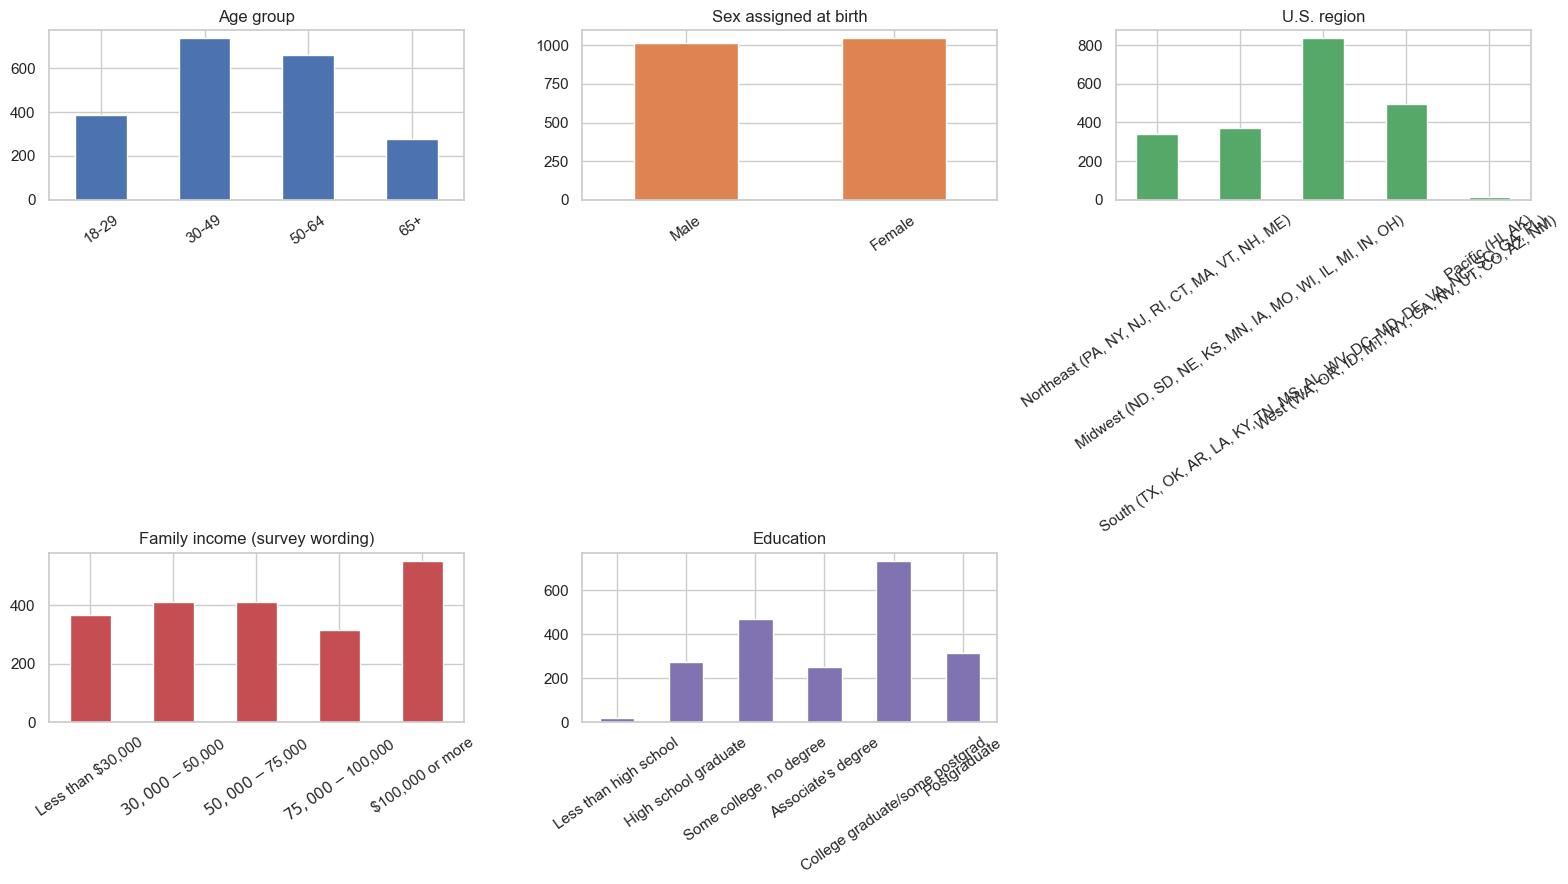

In [11]:
def option_labels(qid: str) -> dict:
    q = next(x for x in question_catalog if x.get("QuestionID") == qid)
    return {i + 1: lab for i, lab in enumerate(q.get("Options") or [])}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("age", "Age group", axes[0, 0], "#4C72B0"),
    ("gender", "Sex assigned at birth", axes[0, 1], "#DD8452"),
    ("region", "U.S. region", axes[0, 2], "#55A868"),
    ("income", "Family income (survey wording)", axes[1, 0], "#C44E52"),
    ("education", "Education", axes[1, 1], "#8172B2"),
]

for key, title, ax, color in plot_specs:
    col = DEMO_COLS[key]
    labels = option_labels(col)
    series = demo_df[col].map(labels)
    order = list(labels.values())
    series.value_counts().reindex(order).plot.bar(ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=35)

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()


**Representativeness check.** The next cell compares five survey marginals with 2023 Census/ACS estimates. Important comparability limits remain: ACS education statistics cover adults aged 25+ while the survey includes ages 18–24; ACS uses household income while the survey asks about family income; the $30k income boundary is interpolated from ACS bins; and the survey separates Pacific (AK/HI) from Census West. The >5 percentage-point flag is only a transparent descriptive threshold, not evidence from a hypothesis test.


In [12]:
# ACS 2023 1-year estimates recoded onto the survey's option labels.
# Sources: Census ACS 2023 S0101 (age, 18+), B01001 (sex), PEP 2023 (region),
# S1501 (education, ages 25+), S1901 (household income). Income ACS bins do not
# split at $30k; <30k / 30-50k are interpolated from the $25-35k ACS bin.
ACS_2023 = {
    "age": {"18-29": 0.199, "30-49": 0.333, "50-64": 0.238, "65+": 0.226},
    "gender": {"Male": 0.490, "Female": 0.510},
    "region": {
        "Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)": 0.170,
        "Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, IN, OH)": 0.206,
        "South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL)": 0.386,
        "West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)": 0.232,  # Census West minus AK/HI
        "Pacific (HI, AK)": 0.006,
    },
    "income": {
        "Less than $30,000": 0.190,
        "$30,000-$50,000": 0.143,
        "$50,000-$75,000": 0.162,
        "$75,000-$100,000": 0.127,
        "$100,000 or more": 0.378,
    },
    "education": {
        "Less than high school": 0.102,
        "High school graduate": 0.259,
        "Some college, no degree": 0.191,
        "Associate's degree": 0.087,
        "College graduate/some postgrad": 0.218,  # ACS Bachelor's
        "Postgraduate": 0.143,
    },
}

rows = []
for key, qid in DEMO_COLS.items():
    labels = option_labels(qid)
    sample = demo_df[qid].map(labels).value_counts(normalize=True)
    for lab in labels.values():
        s = float(sample.get(lab, np.nan))
        a = ACS_2023[key].get(lab, np.nan)
        rows.append({
            "variable": key,
            "bin": lab,
            "sample_share": s,
            "acs_share": a,
            "delta_pp": (s - a) * 100 if pd.notna(s) and pd.notna(a) else np.nan,
        })

representativeness_df = pd.DataFrame(rows)
print("Sample vs ACS 2023 (percentage-point gap = sample - ACS)")
print(representativeness_df.assign(
    sample_share=lambda d: (d.sample_share * 100).round(1),
    acs_share=lambda d: (d.acs_share * 100).round(1),
    delta_pp=lambda d: d.delta_pp.round(1),
).to_string(index=False))
print()
big = representativeness_df[representativeness_df["delta_pp"].abs() > 5]
print(f"Gaps >5pp ({len(big)} bins):")
print(big.sort_values("delta_pp", key=lambda s: s.abs(), ascending=False).to_string(index=False))


Sample vs ACS 2023 (percentage-point gap = sample - ACS)
 variable                                                                        bin  sample_share  acs_share  delta_pp
      age                                                                      18-29          18.9       19.9      -1.0
      age                                                                      30-49          35.7       33.3       2.4
      age                                                                      50-64          32.0       23.8       8.2
      age                                                                        65+          13.5       22.6      -9.1
   gender                                                                       Male          49.3       49.0       0.3
   gender                                                                     Female          50.7       51.0      -0.3
   region                             Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)          16.6     

## 5. Human test–retest benchmark


Wave 4 was launched approximately **two weeks after wave 3** and repeats heuristics, behavioral-economics, and pricing items from waves 1–3. Items originally administered in earlier waves have a longer interval. This section measures short-term self-consistency for the held-out prediction items; it is not a general constant for how stable a person is.

The standardized response CSVs have 126 repeated response columns. Each column is mapped through the catalog's `csv_columns` field and summarized with a type-appropriate diagnostic:
- **Single-choice MC:** exact-match accuracy and Cohen's κ.
- **Ordered Matrix:** exact match, ordinal MAE, and ICC(A,1).
- **Slider (0–100):** MAE, Pearson r, and ICC(A,1); exact match is diagnostic only.
- **Numeric TE:** exact match and Pearson r. Raw MAE is computed per item but is not averaged across TE items because their numerical scales differ.

The values below are unweighted means across response columns within each type. They are descriptive EDA results—not a reproduction of the paper's task-level aggregation. Paper Figure 2 reports **81.72% mean human test–retest accuracy across 17 tasks**, using exact match for binary items, range-normalized accuracy for bounded numerical items, and decile scoring for unbounded anchoring responses.

In [13]:
# wave1_3_response.csv has 761 cols, wave4_response.csv has 127 -- the overlap is exactly
# the repeated-question set. Intersect on column name (both use {QID}_{SubID} convention).
w13_cols = set(w13_num.columns) - {"pid"}
w4_cols  = set(w4_num.columns) - {"pid"}
overlap_cols = sorted(w13_cols & w4_cols)

print(f"{len(overlap_cols)} columns appear in BOTH wave1-3 and wave4 response files.")
print("First 10:", overlap_cols[:10])


126 columns appear in BOTH wave1-3 and wave4 response files.
First 10: ['QID154', 'QID156', 'QID157', 'QID158', 'QID159_1', 'QID159_2', 'QID159_3', 'QID160_1', 'QID160_2', 'QID160_3']


In [14]:
merged = w13_num[["pid"] + overlap_cols].merge(
    w4_num[["pid"] + overlap_cols], on="pid", suffixes=("_w13", "_w4")
)

def cohens_kappa(a, b) -> float:
    a = np.asarray(a)
    b = np.asarray(b)
    po = np.mean(a == b)
    labels = np.unique(np.concatenate([a, b]))
    pe = sum(np.mean(a == lab) * np.mean(b == lab) for lab in labels)
    if pe >= 1.0:
        return 1.0 if po == 1.0 else 0.0
    return float((po - pe) / (1.0 - pe))

def icc_a1(a, b) -> float:
    """ICC(A,1) absolute agreement, two-way random / Shrout-Fleiss ICC(2,1)."""
    Y = np.column_stack([np.asarray(a, float), np.asarray(b, float)])
    n, k = Y.shape
    if n < 3:
        return np.nan
    mu = Y.mean()
    mean_i, mean_j = Y.mean(axis=1), Y.mean(axis=0)
    ssr = k * np.sum((mean_i - mu) ** 2)
    ssc = n * np.sum((mean_j - mu) ** 2)
    sse = np.sum((Y - mu) ** 2) - ssr - ssc
    msr = ssr / (n - 1)
    mse = sse / ((n - 1) * (k - 1))
    msc = ssc / (k - 1)
    denom = msr + (k - 1) * mse + k * (msc - mse) / n
    if denom == 0:
        return np.nan
    return float((msr - mse) / denom)

records = []
for col in overlap_cols:
    meta = question_meta(col)
    a_raw = merged[f"{col}_w13"]
    b_raw = merged[f"{col}_w4"]
    pair = a_raw.notna() & b_raw.notna()
    n_pair = int(pair.sum())
    miss_w4 = float(b_raw.isna().mean())
    if n_pair < 30:
        continue
    a, b = a_raw[pair], b_raw[pair]
    exact = float((a == b).mean())
    kappa = (
        cohens_kappa(a.astype(str).to_numpy(), b.astype(str).to_numpy())
        if meta["qtype"] in {"MC", "Matrix"}
        else np.nan
    )
    a_num = pd.to_numeric(a, errors="coerce")
    b_num = pd.to_numeric(b, errors="coerce")
    num_ok = a_num.notna() & b_num.notna()
    mad = pearson = icc = np.nan
    if meta["qtype"] in {"Matrix", "Slider", "TE"} and int(num_ok.sum()) >= 30:
        an, bn = a_num[num_ok], b_num[num_ok]
        mad = float((an - bn).abs().mean())
        if an.nunique() > 1 and bn.nunique() > 1:
            pearson = float(an.corr(bn))
        icc = icc_a1(an.to_numpy(), bn.to_numpy())
    records.append({
        "column": col,
        "qid": meta["qid"],
        "qtype": meta["qtype"],
        "selector": meta["selector"],
        "block": meta["block"],
        "n": n_pair,
        "wave4_missing_rate": miss_w4,
        "likely_between_subject": miss_w4 > 0.35,
        "exact_match_rate": exact,
        "cohen_kappa": kappa,
        "mean_abs_diff": mad,
        "pearson_r": pearson,
        "icc_a1": icc,
    })

reliability_df = pd.DataFrame(records)
print("Type counts in the 126-item overlap (via csv_columns, not QID prefix):")
print(reliability_df["qtype"].value_counts().to_string())
mc = reliability_df[reliability_df["qtype"] == "MC"]
print("\nMC selectors in that overlap (CSV columns; wave-4 scored set, not the 256-QID catalog):")
print(mc["selector"].value_counts().to_string())
print("unique MC QuestionIDs by selector:")
print(mc.drop_duplicates("qid")["selector"].value_counts().to_string())
print("\nUnique QuestionIDs in the 126-column overlap by qtype (not column counts):")
print(reliability_df.drop_duplicates("qid")["qtype"].value_counts().to_string())
reliability_df.sort_values("exact_match_rate").head(15)


Type counts in the 126-item overlap (via csv_columns, not QID prefix):
qtype
MC        68
Matrix    40
Slider    12
TE         6

MC selectors in that overlap (CSV columns; wave-4 scored set, not the 256-QID catalog):
selector
SAVR    53
SAHR    15
unique MC QuestionIDs by selector:
selector
SAVR    53
SAHR    15

Unique QuestionIDs in the 126-column overlap by qtype (not column counts):
qtype
MC        68
Matrix     7
TE         6
Slider     3


,column,qid,qtype,selector,block,n,wave4_missing_rate,likely_between_subject,exact_match_rate,cohen_kappa,mean_abs_diff,pearson_r,icc_a1
82,QID290_5,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.077259,NaN,15.983965,0.450020,0.447508
83,QID290_6,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.081633,NaN,15.471331,0.461891,0.461997
80,QID290_3,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.082119,NaN,15.147230,0.582698,0.579772
81,QID290_4,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.083090,NaN,15.335763,0.548600,0.548633
78,QID290_12,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.084062,NaN,16.178328,0.522084,0.520956
79,QID290_2,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.084062,NaN,15.440719,0.505032,0.502291
76,QID290_10,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.086978,NaN,16.285714,0.545427,0.544668
77,QID290_11,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.093294,NaN,14.978134,0.529670,0.529554
84,QID290_7,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.097668,NaN,14.435374,0.548364,0.548422
75,QID290_1,QID290,Slider,HSLIDER,Non-experimental heuristics and biases,2058,0.000000,False,0.113217,NaN,13.565112,0.572576,0.572427


In [15]:
print("=== Descriptive human test-retest results for repeated wave-4 items ===")
print(f"Response columns compared: {len(reliability_df)}")
print("Values are unweighted means across response columns within each type.")
print("Do not pool these into one score: the metrics and response scales differ by type.")
print()

headline = {
    "MC": ["exact_match_rate", "cohen_kappa"],
    "Matrix": ["exact_match_rate", "cohen_kappa", "mean_abs_diff", "icc_a1"],
    "Slider": ["mean_abs_diff", "pearson_r", "icc_a1", "exact_match_rate"],
    "TE": ["pearson_r", "exact_match_rate"],
}
summary_rows = []
all_metric_cols = ["exact_match_rate", "cohen_kappa", "mean_abs_diff", "pearson_r", "icc_a1"]
for qtype, cols in headline.items():
    g = reliability_df[reliability_df["qtype"] == qtype]
    if g.empty:
        continue
    means = g[cols].mean()
    print(f"--- {qtype} (n_columns={len(g)}, median n_people={g['n'].median():.0f}) ---")
    print(means.to_string())
    print()
    row = {"qtype": qtype, "n_columns": len(g), "median_n_people": g["n"].median()}
    row.update({metric: np.nan for metric in all_metric_cols})
    row.update(means.to_dict())
    summary_rows.append(row)

reliability_summary_df = pd.DataFrame(summary_rows).set_index("qtype")
reliability_summary_df


=== Descriptive human test-retest results for repeated wave-4 items ===
Response columns compared: 126
Values are unweighted means across response columns within each type.
Do not pool these into one score: the metrics and response scales differ by type.

--- MC (n_columns=68, median n_people=2058) ---
exact_match_rate    0.735047
cohen_kappa         0.541301

--- Matrix (n_columns=40, median n_people=1032) ---
exact_match_rate    0.602896
cohen_kappa         0.298752
mean_abs_diff       0.524072
icc_a1              0.446120

--- Slider (n_columns=12, median n_people=2058) ---
mean_abs_diff       15.488327
pearson_r            0.491358
icc_a1               0.490166
exact_match_rate     0.119947

--- TE (n_columns=6, median n_people=1029) ---
pearson_r           0.383254
exact_match_rate    0.253018



,n_columns,median_n_people,exact_match_rate,cohen_kappa,mean_abs_diff,pearson_r,icc_a1
qtype,,,,,,,
MC,68,2058.0,0.735047,0.541301,NaN,NaN,NaN
Matrix,40,1032.0,0.602896,0.298752,0.524072,NaN,0.446120
Slider,12,2058.0,0.119947,NaN,15.488327,0.491358,0.490166
TE,6,1029.0,0.253018,NaN,NaN,0.383254,NaN


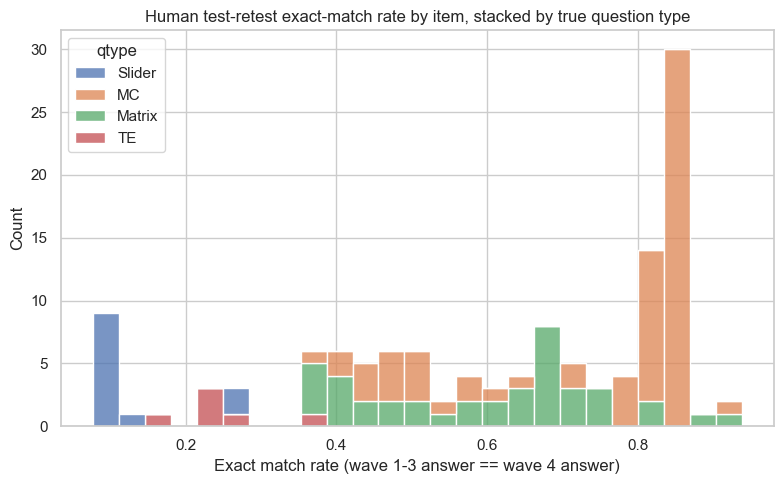

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=reliability_df, x="exact_match_rate", hue="qtype", bins=25, ax=ax, multiple="stack")
ax.set_title("Human test-retest exact-match rate by item, stacked by true question type")
ax.set_xlabel("Exact match rate (wave 1-3 answer == wave 4 answer)")
plt.tight_layout()
plt.show()


**How to read the benchmark.** Report results by question type using the evaluation metric appropriate to that type (Section 3). Human test–retest is an empirical reference point, not a strict mathematical ceiling: a model can exceed it for legitimate reasons, but an unexpectedly high result should trigger checks for target leakage, copied earlier answers, and overfitting. Wave 4 does not re-ask demographics or Big Five, so these statistics say nothing about those constructs. Slider exact match is only about 12% even when Pearson r and ICC are moderate; this reflects the granularity of a 0–100 scale, not evidence that respondents answered randomly.


## 6. Leakage trap


Wave 4 repeats questions from waves 1–3, which creates one leakage trap and one input-condition distinction:

1. **`full_persona.persona_text` and `persona_json` contain wave-4 answers for repeated items.** The dataset card states that wave-4 responses replace earlier responses when a question appears in both periods. Conditioning on these fields while predicting wave 4 directly exposes the target.
2. **`wave4_Q_wave1_3_A` contains the participant's earlier answer to the same held-out item.** That earlier answer is temporally valid history, not a wave-4 label leak. It is used for test-retest and copy-last, and it may enter a separately reported full-history condition. It must not enter the primary no-copy model input.

`wave_split.wave1_3_persona_*` is the correct starting point, but the final model input must still exclude answers attached to held-out wave-4 question payloads. The next cell fixes the demonstration to `pid=1 / QID154` and asserts all four relevant values: earlier CSV answer 70, wave-4 CSV answer 82, earlier-answer payload 70, and wave-4 payload/full-persona value 82. An empty QID154 match in `wave1_3_persona_json` is expected because repeated target items are separated into the two wave-4 question fields.

In [17]:
# Fixed, reproducible spot check used in the report: pid=1 / QID154.
def iter_questions(obj):
    if isinstance(obj, dict):
        if obj.get("QuestionID") is not None and "Answers" in obj:
            yield obj
        for value in obj.values():
            yield from iter_questions(value)
    elif isinstance(obj, list):
        for value in obj:
            yield from iter_questions(value)

def answers_for_qid(payload, qid):
    blob = json.loads(payload) if isinstance(payload, str) else payload
    return [q.get("Answers") for q in iter_questions(blob) if str(q.get("QuestionID")) == str(qid)]

def canonical_token(value):
    try:
        number = float(value)
        return str(int(number)) if number.is_integer() else str(number)
    except (TypeError, ValueError):
        return str(value)

def answer_tokens(answer_groups):
    tokens = []
    def walk(value):
        if isinstance(value, dict):
            for key, nested in value.items():
                if key in {"Values", "SelectedByPosition", "SelectedText"}:
                    walk(nested)
                elif isinstance(nested, (dict, list)):
                    walk(nested)
        elif isinstance(value, list):
            for nested in value:
                walk(nested)
        elif value is not None:
            tokens.append(canonical_token(value))
    walk(answer_groups)
    return tokens

sample_pid = 1
sample_col = "QID154"
qid = question_meta(sample_col)["qid"]
assert sample_col in overlap_cols and qid == "QID154"

w13_answer = w13_num.loc[w13_num.pid == sample_pid, sample_col].iloc[0]
w4_answer = w4_num.loc[w4_num.pid == sample_pid, sample_col].iloc[0]
w13_token, w4_token = canonical_token(w13_answer), canonical_token(w4_answer)
assert (w13_token, w4_token) == ("70", "82")

fp_row = full_persona.loc[full_persona.pid == sample_pid].iloc[0]
ws_row = wave_split.loc[wave_split.pid == sample_pid].iloc[0]
fp_ans = answers_for_qid(fp_row["persona_json"], qid)
ws_persona_ans = answers_for_qid(ws_row["wave1_3_persona_json"], qid)
earlier_payload_ans = answers_for_qid(ws_row["wave4_Q_wave1_3_A"], qid)
wave4_payload_ans = answers_for_qid(ws_row["wave4_Q_wave4_A"], qid)

assert w4_token in answer_tokens(fp_ans)
assert ws_persona_ans == []
assert w13_token in answer_tokens(earlier_payload_ans)
assert w4_token in answer_tokens(wave4_payload_ans)

fp_text = str(fp_row["persona_text"])
expected_text = f"Answer: {w4_token}"
assert expected_text in fp_text

print(f"pid={sample_pid}  column={sample_col}  QuestionID={qid}  type={question_meta(sample_col)['qtype']}")
print(f"  CSV wave 1-3 answer                    : {w13_answer}")
print(f"  CSV wave 4 answer                      : {w4_answer}")
print(f"  full_persona.persona_json Answers      : {fp_ans}")
print(f"  wave1_3_persona_json Answers           : {ws_persona_ans}")
print(f"  wave4_Q_wave1_3_A Answers              : {earlier_payload_ans}")
print(f"  wave4_Q_wave4_A Answers                : {wave4_payload_ans}")
print(f"  persona_text contains {expected_text!r}       : {expected_text in fp_text}")

fp_summary = str(fp_row["persona_summary"])
summary_value_check = {
    token: bool(re.search(rf"(?<!\\d){re.escape(token)}(?!\\d)", fp_summary))
    for token in (w13_token, w4_token)
}
print(f"  persona_summary crude value check      : {summary_value_check}")
print("  Note: value substrings alone cannot establish whether persona_summary is leakage-safe.")
print("Assertions confirm that full_persona exposes the wave-4 target while wave_split keeps the earlier and wave-4 answers in separate fields.")


pid=1  column=QID154  QuestionID=QID154  type=Slider
  CSV wave 1-3 answer                    : 70.0
  CSV wave 4 answer                      : 82.0
  full_persona.persona_json Answers      : [{'Values': ['82']}]
  wave1_3_persona_json Answers           : []
  wave4_Q_wave1_3_A Answers              : [{'Values': ['70']}]
  wave4_Q_wave4_A Answers                : [{'Values': ['82']}]
  persona_text contains 'Answer: 82'       : True
  persona_summary crude value check      : {'70': False, '82': False}
  Note: value substrings alone cannot establish whether persona_summary is leakage-safe.
Assertions confirm that full_persona exposes the wave-4 target while wave_split keeps the earlier and wave-4 answers in separate fields.


In [18]:
leak_risk_share = len(overlap_cols) / len(w13_cols)
print(f"{len(overlap_cols)} / {len(w13_cols)} (~{leak_risk_share:.1%}) of wave1-3 columns "
      f"are re-asked in wave 4 -> every one of these is a potential leak point if the wrong "
      f"persona field is used as model input.")


126 / 760 (~16.6%) of wave1-3 columns are re-asked in wave 4 -> every one of these is a potential leak point if the wrong persona field is used as model input.


## 7. Biases and limitations


- **Selection and completion bias.** Recruitment used a Prolific online panel, and the dataset card warns of self-selection. The final sample contains 2,058 four-wave completers, down from 2,509 wave-1 completions, so it may differ from people who do not join online panels or who did not complete every wave. The ACS comparison also shows substantial education differences.
- **Self-report bias.** The dataset card warns of social-desirability bias. These data measure reported survey responses, not directly observed behavior.
- **Short and limited retest.** Wave 4 was launched approximately two weeks after wave 3, while items first asked in earlier waves have a longer interval. It repeats only selected heuristics, behavioral-economics, and pricing tasks, so the benchmark does not establish long-term stability or cover demographics and personality items.
- **Time and geographic scope.** The paper describes a U.S. panel surveyed in January–February 2025. Results may not generalize to other countries, periods, or populations.
- **Structured wave-4 missingness.** The two standardized CSVs contain the same 2,058 final-sample `pid`s. Many blank wave-4 cells occur because between-subject experiments assign a participant to one condition, not because that participant dropped out. This item-level missingness is separate from the earlier reduction from 2,509 wave-1 completions to 2,058 final participants.

In [19]:
# PID parity within the released final-sample CSVs; this does not measure earlier-wave attrition.
missing_in_w4 = set(w13_num["pid"]) - set(w4_num["pid"])
print(f"Final-sample pids in wave1-3 CSV but absent from wave4 CSV: {len(missing_in_w4)} "
      f"({len(missing_in_w4) / w13_num['pid'].nunique():.1%}).")
print("This parity check is separate from the reported reduction from 2,509 wave-1 completions to 2,058 final participants.")

miss_rows = []
for col in overlap_cols:
    meta = question_meta(col)
    miss_rows.append({
        "column": col,
        "qtype": meta["qtype"],
        "block": meta["block"],
        "missing_rate": float(merged[f"{col}_w4"].isna().mean()),
    })
item_missing_df = pd.DataFrame(miss_rows).sort_values("missing_rate", ascending=False)
item_missing = item_missing_df.set_index("column")["missing_rate"]  # used by the Excel export

print(f"Overlap items with wave4 missing >40%: {(item_missing_df.missing_rate > 0.4).sum()} / {len(item_missing_df)}")
print("Highest-missing items (block names are experimental arms, not 'people dropped out'):")
display_cols = ["column", "block", "missing_rate"]
print(item_missing_df.head(10)[display_cols].to_string(index=False))

# Complementarity check: anchoring high vs low should partition the sample.
def cols_for_block_contains(*needles):
    needles = tuple(n.lower() for n in needles)
    return [c for c in overlap_cols
            if all(n in question_meta(c)["block"].lower() for n in needles)]

high = cols_for_block_contains("anchoring", "african", "high")
low = cols_for_block_contains("anchoring", "african", "low")
if high and low:
    h, l = high[0], low[0]
    both = merged[f"{h}_w4"].notna() & merged[f"{l}_w4"].notna()
    either = merged[f"{h}_w4"].notna() | merged[f"{l}_w4"].notna()
    print(f"\nBetween-subject check: {h} ({question_meta(h)['block']}) vs {l} ({question_meta(l)['block']})")
    print(f"  answered HIGH: {int(merged[f'{h}_w4'].notna().sum())}")
    print(f"  answered LOW : {int(merged[f'{l}_w4'].notna().sum())}")
    print(f"  answered BOTH (should be ~0): {int(both.sum())}")
    print(f"  answered either: {int(either.sum())} / {len(merged)}")


Final-sample pids in wave1-3 CSV but absent from wave4 CSV: 0 (0.0%).
This parity check is separate from the reported reduction from 2,509 wave-1 completions to 2,058 final participants.
Overlap items with wave4 missing >40%: 56 / 126
Highest-missing items (block names are experimental arms, not 'people dropped out'):
column                                  block  missing_rate
QID179                Proportion dominance 2C      0.683673
QID176                Proportion dominance 1C      0.683673
QID173                  Less is More Gamble C      0.683673
QID172                  Less is More Gamble B      0.673469
QID178                Proportion dominance 2B      0.673469
QID175                Proportion dominance 1B      0.673469
QID190 WTA/WTP Thaler problem - WTA certainty      0.672983
QID191      WTA/WTP Thaler - WTP noncertainty      0.672983
QID189 WTA/WTP Thaler problem - WTP certainty      0.654033
QID171                  Less is More Gamble A      0.642857

Between-subject che

## 8. Export


Jupyter/`pandas` truncates wide tables and long text fields in the notebook display. The cells below write the full analytical tables to one multi-sheet `.xlsx` for inspection in Excel.

Sheets:
- `question_catalog` — full catalog metadata
- `qtype_scoring` — question-type-to-metric mapping
- `reliability` — per-response-column test–retest diagnostics
- `reliability_summary` — type-specific summaries with inapplicable metrics left blank
- `demographics` — all 2,058 final-sample rows for the five demographic columns
- `representativeness` — sample shares, Census benchmarks, and percentage-point gaps
- `item_missingness` — per-item missingness in repeated wave-4 columns
- `persona_sample` — the first 25 participants' long persona text fields for spot checks

Only in-memory results computed above are exported, so run all prior cells first.

In [20]:
from pathlib import Path

cwd = Path.cwd().resolve()
if (cwd / "docs").is_dir() and (cwd / "notebooks").is_dir():
    RESULTS_DIR = cwd / "results"
elif (cwd / "data_exploration.ipynb").exists():
    RESULTS_DIR = cwd.parent / "results"
else:
    RESULTS_DIR = cwd / "results"
    for parent in [cwd, *cwd.parents]:
        if (parent / "docs" / "01_data_exploration.md").exists():
            RESULTS_DIR = parent / "results"
            break

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = (RESULTS_DIR / "data_exploration_export.xlsx").resolve()

# Full question catalog as a flat table (QuestionID/QuestionType/etc. + options as a joined string)
catalog_rows = []
for q in question_catalog:
    opts = q.get("Options")
    catalog_rows.append({
        "QuestionID": q.get("QuestionID"),
        "QuestionText": q.get("QuestionText"),
        "QuestionType": q.get("QuestionType"),
        "CSV_columns": "; ".join(q.get("csv_columns") or []),
        "Selector": (q.get("Settings") or {}).get("Selector"),
        "is_descriptive": q.get("is_descriptive"),
        "Options": "; ".join(opts) if isinstance(opts, list) else opts,
    })
catalog_export_df = pd.DataFrame(catalog_rows)

# Persona text sample -- untruncated, first 25 people
if "full_persona" in globals() and len(full_persona) and "persona_text" in full_persona.columns:
    persona_cols = [c for c in ["pid", "persona_summary", "persona_text"] if c in full_persona.columns]
    persona_sample_df = full_persona[persona_cols].head(25)
else:
    persona_sample_df = pd.DataFrame(
        {"note": ["full_persona not loaded — run Section 2 / leakage cells first"]}
    )

with pd.ExcelWriter(EXPORT_PATH, engine="openpyxl") as writer:
    catalog_export_df.to_excel(writer, sheet_name="question_catalog", index=False)
    qtype_df.to_excel(writer, sheet_name="qtype_scoring", index=False)
    reliability_df.sort_values("exact_match_rate").to_excel(writer, sheet_name="reliability", index=False)
    reliability_summary_df.reset_index().to_excel(
        writer, sheet_name="reliability_summary", index=False
    )
    demo_df.to_excel(writer, sheet_name="demographics", index=False)
    if "representativeness_df" in globals():
        representativeness_df.to_excel(writer, sheet_name="representativeness", index=False)
    item_missing_df.to_excel(writer, sheet_name="item_missingness", index=False)
    persona_sample_df.to_excel(writer, sheet_name="persona_sample", index=False)

print(f"Wrote {EXPORT_PATH}")


Wrote D:\Amity_Assignment\results\data_exploration_export.xlsx


In [21]:
# Auto-fit column widths and freeze the header row so the workbook is actually pleasant to browse.
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

EXPORT_PATH = Path(EXPORT_PATH).resolve()
wb = load_workbook(EXPORT_PATH)
for ws in wb.worksheets:
    ws.freeze_panes = "A2"
    for i, col_cells in enumerate(ws.columns, start=1):
        max_len = max((len(str(c.value)) if c.value is not None else 0) for c in col_cells)
        ws.column_dimensions[get_column_letter(i)].width = min(max(max_len + 2, 10), 60)
wb.save(EXPORT_PATH)

print(f"Formatted and saved: {EXPORT_PATH}")
print("Sheets:", wb.sheetnames)


Formatted and saved: D:\Amity_Assignment\results\data_exploration_export.xlsx
Sheets: ['question_catalog', 'qtype_scoring', 'reliability', 'reliability_summary', 'demographics', 'representativeness', 'item_missingness', 'persona_sample']


> Re-run this section after the analytical cells to refresh `results/data_exploration_export.xlsx`. The notebook remains the reproducible deliverable; the workbook is the inspection export written next to the committed `results/` artifacts.


## 9. Summary


| Finding | Feeds into |
|---|---|
| `full_persona` exposes wave-4 answers for repeated items. Start from `wave_split`, strip answers from held-out question payloads, and retain labels only as targets. | `docs/02_model_plan.md` and `docs/03_eval_strategy.md` |
| Test–retest diagnostics must be reported by response type. The paper's 81.72% across 17 tasks is an empirical benchmark, not a strict upper bound and not recomputed by this notebook. | `docs/03_eval_strategy.md` |
| The catalog contains 21 multi-select MC QuestionIDs, but none occur in the 126-column held-out overlap. `DB` screens have no response columns. Types are mapped through `csv_columns`. | `docs/03_eval_strategy.md` |
| Gender/sex and region are close to Census benchmarks, while education, age, and income show gaps above the descriptive 5-percentage-point threshold. | `docs/04_business_apps.md` |
| Between-subject item missingness is distinct from participant attrition; selection, self-report, retest-window, and geographic/time limitations remain. | `docs/05_maintenance.md` |

Next: `docs/02_model_plan.md` for the modeling approach.